# Teste de treinamento de modelo para predição de Resistência utilizando HGBR

In [23]:
%%capture
!pip install lightgbm optuna

In [26]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.inspection import permutation_importance
from lightgbm import early_stopping
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os

### Montagem do drive

In [27]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_HGBR.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 586 entries, 3 to 598
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Finura_Cimento_Blaine_m2_kg     586 non-null    float64
 1   Agua_kg_m3                      586 non-null    float64
 2   Superplastificante_kg_m3        586 non-null    float64
 3   Relacao_Agua_Cimento            586 non-null    float64
 4   Usa_SP                          586 non-null    bool   
 5   Classe_Cim_OpA                  586 non-null    int64  
 6   Relacao_Agua_Aglomerante        586 non-null    float64
 7   Filer_D50_um                    586 non-null    float64
 8   D_Max                           586 non-null    float64
 9   cod_classe                      586 non-null    int64  
 10  Cluster_ID                      586 non-null    int64  
 11  Massa_Esp_Cimento_kg_m3         586 non-null    float64
 12  Massa_Esp_Areia_kg_m3           586 non-n

In [29]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 18


In [30]:
# Features efetivamente usadas no modelo
X = df.drop(columns=['target', 'Autores/ano'])

# Regras físicas
regras_fisicas = {
    'parametro_feret': 1,
    'ln_Idade': 1,
    'idade_ac': 1,
    'Relacao_Agua_Cimento': -1,
    'Relacao_Agua_Aglomerante': -1,
    'agua_solidos': -1,
    'vol_ar_aprisionado': -1,
    'porosidade_volumetrica_inicial': -1
}

restricoes_completas = []

for coluna in X.columns:

    restricao = regras_fisicas.get(coluna, 0)

    restricoes_completas.append(restricao)

    print(f"{coluna}: {restricao}")

hyper_params = {

    # boosting
    "n_estimators": 250,
    "learning_rate": 0.05,

    # árvore
    "max_depth": 3,
    "max_bin": 64,

    # regularização
    "min_child_samples": 12,
    "reg_lambda": 10.0,

    # monotonicidade
    "monotone_constraints": restricoes_completas,

    # reprodutibilidade
    "random_state": 42,

    # performance
    "verbosity": -1,

    # opcional
    "objective": "regression",
    "metric": "rmse",

    "device": "gpu"  # Use GPU if available
}

Finura_Cimento_Blaine_m2_kg: 0
Agua_kg_m3: 0
Superplastificante_kg_m3: 0
Relacao_Agua_Cimento: -1
Usa_SP: 0
Classe_Cim_OpA: 0
Relacao_Agua_Aglomerante: -1
Filer_D50_um: 0
D_Max: 0
cod_classe: 0
Cluster_ID: 0
Massa_Esp_Cimento_kg_m3: 0
Massa_Esp_Areia_kg_m3: 0
Massa_Esp_Brita_kg_m3: 0
Massa_Esp_Filer_kg_m3: 0
vol_cimento: 0
vol_areia: 0
vol_brita: 0
volume_materiais: 0
vol_ar_aprisionado: -1
porosidade_volumetrica_inicial: -1
vol_solidos_totais: 0
vol_agregados: 0
vol_pasta: 0
vol_po_total: 0
pasta_agregado: 0
aglomerante_total: 0
finos_total: 0
range_granulometrico: 0
parametro_feret: 1
indice_conformidade_feret: 0
feret_corrigido_contorno: 0
pow_interacao_tempo: 0
ryshkewitch_cinetico: 0
hasselman_resiliencia_agua: 0
aci_estimativa_final_MPa: 0
aci_desvio_cimento: 0
s_fib: 0
fib_fator_tempo: 0
fib_estimativa_base: 0
pasta_agregado_fino: 0


In [31]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []

results = []
importancias = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = LGBMRegressor(**hyper_params)

    model.fit(
        X_train,
        y_train,

        eval_set=[
            (X_train, y_train),
            (X_val, y_val)
        ],

        eval_metric='rmse',

        callbacks=[
            early_stopping(50)
        ]
    )

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

    results.append(model.evals_result_)

    importancias.append(model.feature_importances_)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[250]	training's rmse: 2.65257	valid_1's rmse: 7.35677
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[249]	training's rmse: 1.89677	valid_1's rmse: 9.336
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[39]	training's rmse: 5.41933	valid_1's rmse: 4.30658
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[81]	training's rmse: 3.59777	valid_1's rmse: 4.1954
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[250]	training's rmse: 2.44716	valid_1's rmse: 9.4939
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[217]	training's rmse: 2.46886	valid_1's rmse: 7.31704
Training until validation scores don't improve f

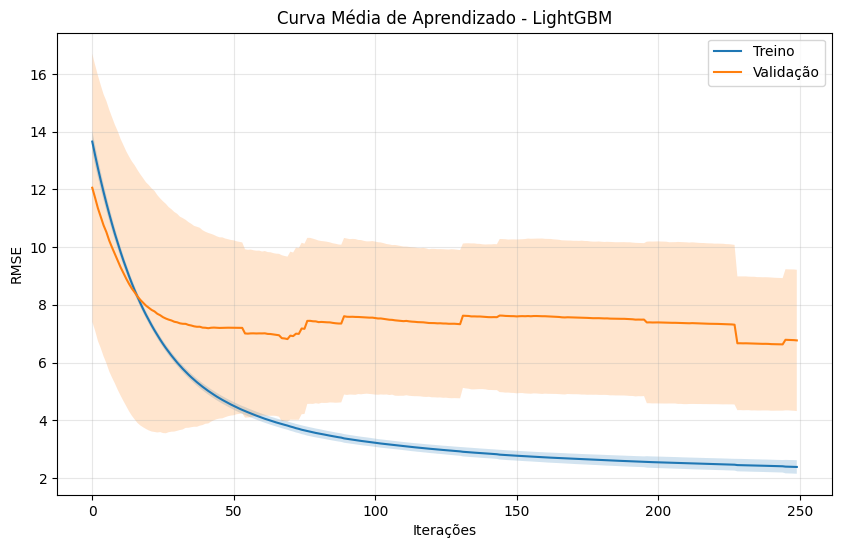

In [33]:
train_curves = []
val_curves = []

for r in results:

    train_curves.append(
        r['training']['rmse']
    )

    val_curves.append(
        r['valid_1']['rmse']
    )

max_len = max(len(c) for c in train_curves)

train_matrix = np.full(
    (len(train_curves), max_len),
    np.nan
)

val_matrix = np.full(
    (len(val_curves), max_len),
    np.nan
)

for i, curve in enumerate(train_curves):
    train_matrix[i, :len(curve)] = curve

for i, curve in enumerate(val_curves):
    val_matrix[i, :len(curve)] = curve

train_mean = np.nanmean(train_matrix, axis=0)
train_std = np.nanstd(train_matrix, axis=0)

val_mean = np.nanmean(val_matrix, axis=0)
val_std = np.nanstd(val_matrix, axis=0)

iterations = np.arange(max_len)

plt.figure(figsize=(10, 6))

# treino
plt.plot(
    iterations,
    train_mean,
    label='Treino'
)

# validação
plt.plot(
    iterations,
    val_mean,
    label='Validação'
)

# faixa treino
plt.fill_between(
    iterations,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

# faixa validação
plt.fill_between(
    iterations,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Iterações')
plt.ylabel('RMSE')

plt.title('Curva Média de Aprendizado - LightGBM')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [36]:
# Estatísticas finais
train_final = train_mean[-1]
val_final = val_mean[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      2.381720
⚠️  RMSE Validação (final):   6.766750
📈 Gap (Val - Train):        4.385030


In [37]:
debug_df = pd.DataFrame({
    'y_true': np.array(all_true).ravel(),
    'y_pred': np.array(all_preds).ravel(),
    'group': np.array(all_groups).ravel()
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

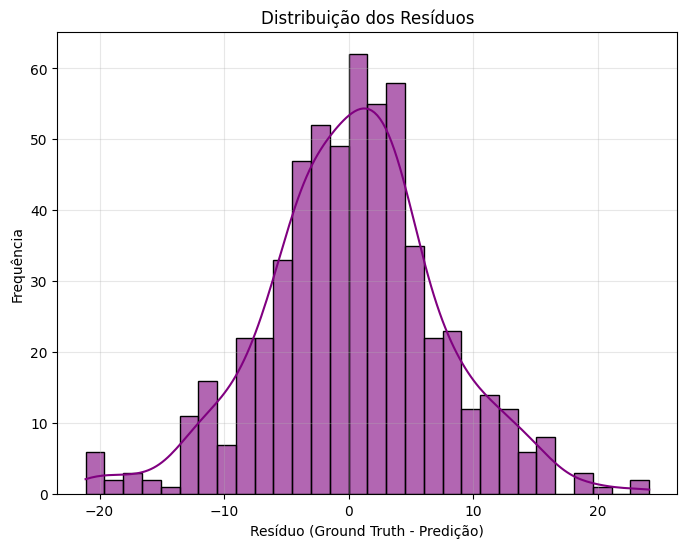

In [38]:
plt.figure(figsize=(8, 6))

sns.histplot(
    debug_df['residual'],
    bins=30,
    kde=True,
    color='purple',
    alpha=0.6
)

plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")

plt.grid(True, alpha=0.3)

plt.show()

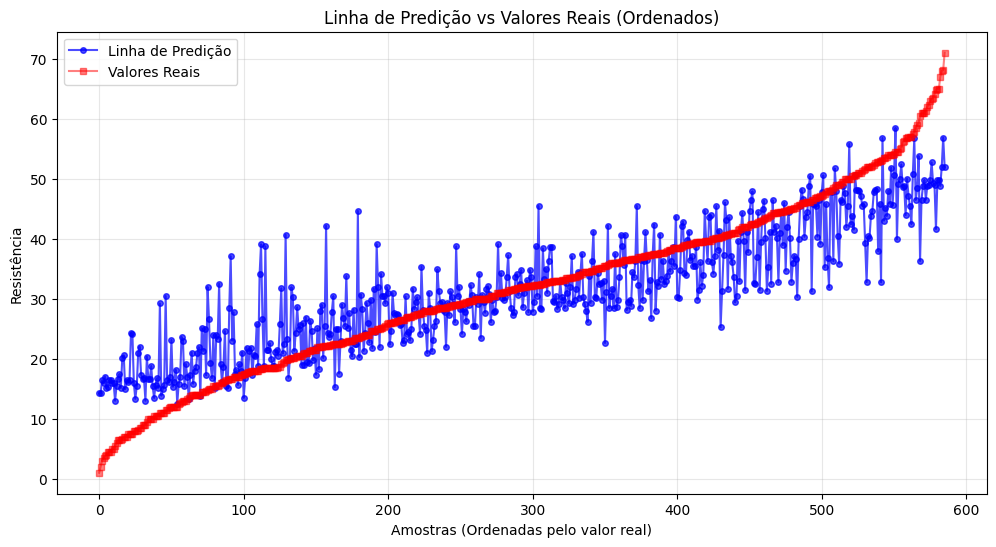

In [39]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 7.0655
mean_absolute_error: 5.4060
mean_absolute_percentage_error: 0.2989
R² Score: 75.2197


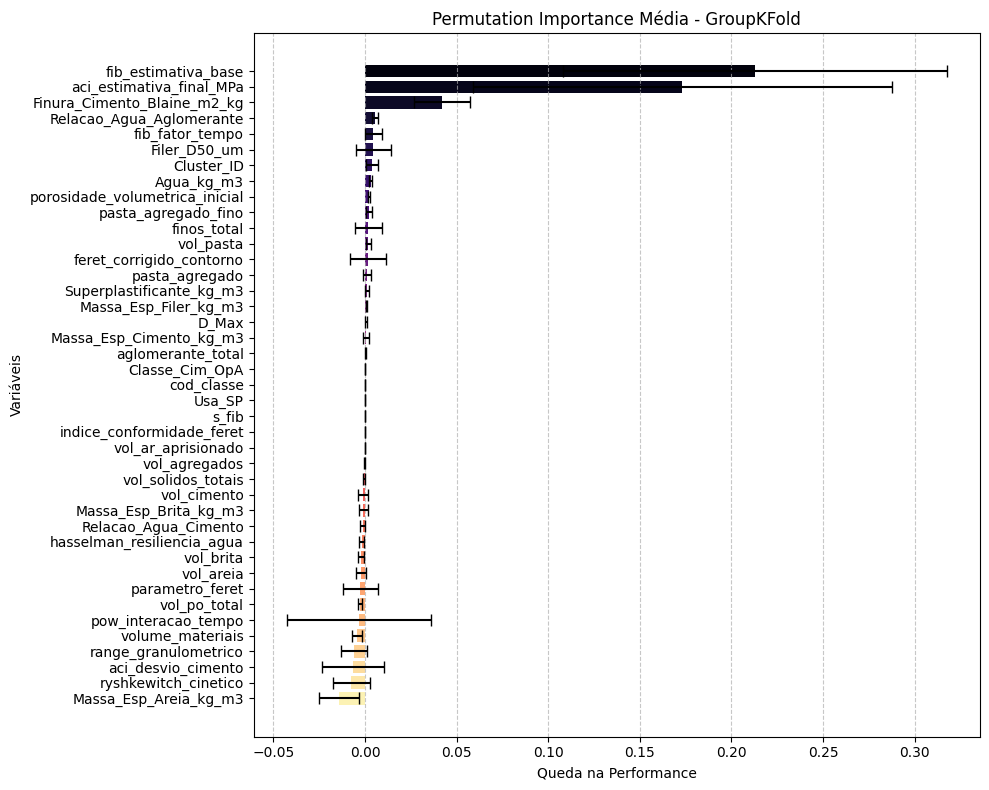

In [41]:
df_importancias = pd.concat(importancias_folds)

df_importancia_hgbr = (
    df_importancias
    .groupby('Feature')
    .agg({
        'Importancia_Media': 'mean',
        'Desvio_Padrao': 'mean'
    })
    .reset_index()
)

# Ordenando da mais importante para a menos importante
df_importancia_hgbr = df_importancia_hgbr.sort_values(by='Importancia_Media', ascending=False)

plt.figure(figsize=(10, 8))

cores = sns.color_palette(
    'magma',
    n_colors=len(df_importancia_hgbr)
)

plt.barh(
    y=df_importancia_hgbr['Feature'],
    width=df_importancia_hgbr['Importancia_Media'],
    xerr=df_importancia_hgbr['Desvio_Padrao'],
    color=cores,
    capsize=4,
    edgecolor='none'
)

plt.gca().invert_yaxis()

plt.title('Permutation Importance Média - GroupKFold')
plt.xlabel('Queda na Performance')
plt.ylabel('Variáveis')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()